# Caso Studio: Previsione Prezzi Immobiliari

---

**L'obiettivo**

Usiamo un dataset reale con dati di circa 20.000 quartieri della
California. Per ognuno conosciamo alcune informazioni: reddito medio
degli abitanti, età degli edifici, numero di stanze, quante persone ci
vivono, posizione geografica.

Il **target**, cioè quello che il modello deve imparare a prevedere, è
il **valore mediano delle case** in quel quartiere (in centinaia di
migliaia di dollari: 3.5 significa 350.000 $).

Il modello impara la relazione tra queste caratteristiche e il prezzo su
una parte dei dati, poi lo testiamo su quartieri mai visti prima — così
scopriamo se funziona anche su casi nuovi, non solo su quelli che già
conosce.


## Import e setup

Importiamo le librerie: `fetch_california_housing` per caricare il
dataset reale, `numpy`/`pandas` per i dati, gli strumenti di
scikit-learn per split, scaling, i tre modelli lineari, la pipeline e le
metriche di valutazione.

In [ ]:
# Funzione che scarica (la prima volta) e carica il dataset reale
from sklearn.datasets import fetch_california_housing

import numpy as np                 # array e calcolo numerico
import pandas as pd                # tabelle (DataFrame) e lettura/gestione dati tabellari
import matplotlib.pyplot as plt    # creazione di grafici

# Strumenti di scikit-learn usati in questo notebook
from sklearn.model_selection import train_test_split, GridSearchCV   # split dei dati e ricerca iperparametri
from sklearn.preprocessing import StandardScaler, PolynomialFeatures  # standardizzazione e feature polinomiali
from sklearn.linear_model import LinearRegression, Ridge, Lasso       # i tre modelli lineari che confrontiamo
from sklearn.pipeline import Pipeline                                  # per concatenare piu passaggi in un unico oggetto
from sklearn.metrics import r2_score, mean_squared_error               # metriche di valutazione

# Impostazione della dimensione di default dei grafici, cosi non dobbiamo
# ripeterla in ogni cella che disegna qualcosa
plt.rcParams["figure.figsize"] = (7, 4.5)

## Step 0 — Caricamento del dataset reale

`fetch_california_housing()` restituisce un oggetto "bunch" (simile a un
dizionario) con dentro i dati, il target, i nomi delle colonne e una
descrizione testuale del dataset. Con `as_frame=True` otteniamo
direttamente un DataFrame pandas gia' pronto, con nomi di colonna
leggibili invece di array numpy "anonimi".

In [ ]:
# as_frame=True chiede a scikit-learn di restituire i dati gia' come
# DataFrame pandas, con nomi di colonna leggibili, invece di array numpy grezzi.
dati = fetch_california_housing(as_frame=True)

# .frame contiene sia le 8 feature sia il target, tutti insieme in un'unica tabella:
# comodo per ispezionare i dati con gli strumenti di pandas (es. .corr(), .describe())
df = dati.frame


df.head()  # mostriamo le prime 5 righe per un controllo visivo veloce

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 1 — Capire le colonne del dataset

Le 8 feature del California Housing 
- **MedInc** — reddito mediano del blocco (in decine di migliaia di $)
- **HouseAge** — eta mediana degli edifici nel blocco (anni)
- **AveRooms** — numero medio di stanze per abitazione
- **AveBedrms** — numero medio di camere da letto per abitazione
- **Population** — popolazione del blocco
- **AveOccup** — numero medio di occupanti per abitazione
- **Latitude**, **Longitude** — coordinate geografiche del blocco

Il target, **MedHouseVal**, e' il valore mediano delle abitazioni nel
blocco, espresso in centinaia di migliaia di dollari (es. 3.5 = 350.000$).

In [61]:
# .info() mostra, per ogni colonna: tipo di dato e presenza di valori mancanti
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [62]:
# .describe() calcola statistiche riassuntive (media, min, max, quartili)
# per ogni colonna numerica: un primo sguardo veloce alla scala dei dati
df.describe().round(2) #metodo di pandas che arrotonda tutti i numeri del risultato a due cifre decimali

#25 50 e 75 rappresentano i quartili: dividono i dati ordinati dal più piccolo al più grande in quattro parti uguali.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


## Step 2 — Separiamo feature (X) e target (y)

`df` (il nostro dataset) contiene sia le feature sia il target nella stessa
tabella: separiamo le due parti per poterli utilizzare per addestrare un modello

In [63]:
# .drop(columns=[...]) restituisce il df (dataset) SENZA la colonna indicata
X = df.drop(columns=["MedHouseVal"]).values   # .values converte da DataFrame ad array numpy (convertiamo il dato perche in bse a ciò che dobbiamo fare e in base ai metodi che cioccorrono per fare analisi)

# selezioniamo solo la colonna del target
y = df["MedHouseVal"].values                    

print("Forma di X (osservazioni, feature):", X.shape) #shape converte il dato in una tupla e quindi immutabile (la lista è mutabile)
print("Forma di y (target):", y.shape)

Forma di X (osservazioni, feature): (20640, 8)
Forma di y (target): (20640,)


## Step 3 — Split 80/20 (train/test)

`train_test_split` divide casualmente le righe: l'80% in training (per
imparare i pesi), il 20% in test (mai visto durante l'addestramento,
usato solo per la valutazione finale). `random_state` fissa il seme
casuale dello split, cosi il risultato e' riproducibile.

In [1]:
# test_size=0.20 lascia il 20% delle osservazioni fuori dall'addestramento
# random_state=42 fissa il seme casuale: rieseguendo lo script otteniamo
# sempre la stessa divisione tra train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42 #quindi utilizzerà sempre stesse righe sia per il train e sia per la val
)

print("Osservazioni di training:", X_train.shape[0])   # 16.500 osservazioni
print("Osservazioni di test:", X_test.shape[0])          # 4.100 osservazioni

NameError: name 'train_test_split' is not defined

## Step 4 — Standardizzazione delle feature

Le 8 feature hanno scale molto diverse (il reddito mediano e' un numero
piccolo tipo 3-8, la popolazione puo' arrivare a migliaia): senza
sandardizzare, i modelli regolarizzati penalizzerebbero le feature in
modo ingiusto solo perche' hanno numeri piu' grandi. `StandardScaler`
porta ogni feature a media 0 e deviazione standard 1.

**Punto critico:** `.fit_transform()` si usa solo sul training set
(impara media e deviazione standard da li'); sul test set si usa solo
`.transform()`, riapplicando gli stessi parametri appresi sul training —
altrimenti il modello "sbircerebbe" informazioni dal test set.

In [65]:
scaler = StandardScaler()

# .fit_transform() fa due cose in un solo passaggio: IMPARA media e
# deviazione standard di ogni feature dal training set (.fit), poi
# trasforma subito i dati di training usando quei valori (.transform)
X_train_scaled = scaler.fit_transform(X_train)

# Sul test set usiamo SOLO .transform(): riapplichiamo gli stessi
# parametri (media, deviazione standard) gia' appresi sul training,
# senza ricalcolarli
X_test_scaled = scaler.transform(X_test)

# Verifica: dopo lo scaling, ogni feature del training deve avere
# media molto vicina a 0 e deviazione standard molto vicina a 1
print("Media feature di training dopo scaling:", np.round(X_train_scaled.mean(axis=0), 3)) 
print("Dev. std feature di training dopo scaling:", np.round(X_train_scaled.std(axis=0), 3))

Media feature di training dopo scaling: [-0. -0.  0. -0. -0. -0.  0. -0.]
Dev. std feature di training dopo scaling: [1. 1. 1. 1. 1. 1. 1. 1.]


## Step 5 — Addestriamo piu modelli: OLS come baseline, poi Ridge e Lasso

Non sappiamo in anticipo quale modello funzionerà meglio sui tuoi dati specifici — dipende da come sono fatte le feature (quante sono, se sono correlate tra loro, quanto rumore c'è). L'unico modo serio per scoprirlo è provarli e confrontarli sullo stesso test set, con le stesse metriche (R² e RMSE). los, ridge e lasso non li abbiamo scelti a priori, li abbiamo scelti perché la struttura del dataset (8 feature di tipo diverso, dimensione moderata, sospetto di correlazioni) rendeva sensato testare proprio queste tre ipotesi 

`LinearRegression` e' la stima OLS.
`Ridge` e `Lasso` aggiungono le due penalita quindi scelgono i pesi meno impattanti o eliminano i pesi bassi o uguali a 0 (L2 e L1).
Per ognuno calcoliamo le previsioni sul test set e le due metriche:
**R²** (quanta varianza del target il modello spiega) e **RMSE**
(errore tipico di previsione, nella stessa unita del target — centinaia
di migliaia di dollari).

In [66]:
risultati = []   # lista vuota: qui accumuliamo (nome modello, R2, RMSE) per confrontarli alla fine

# --- OLS: è il modello piu semplice e basilare, se si sbaglia su questo è inurile provare su modelli piu complessi
ols = LinearRegression().fit(X_train_scaled, y_train)   # .fit() calcola i pesi ottimali sul training
pred_ols = ols.predict(X_test_scaled)                     # .predict() applica il modello al test set
risultati.append((
    "OLS (LinReg)",
    r2_score(y_test, pred_ols),                            # R2: quanta varianza del target il modello spiega (1 = perfetto)
    mean_squared_error(y_test, pred_ols) ** 0.5,           # RMSE: radice dell'errore quadratico medio
))

# --- Ridge: aggiunge una penalita sulla somma dei quadrati dei pesi (L2) ---
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)   # alpha e' il parametro lambda visto a lezione
pred_ridge = ridge.predict(X_test_scaled)
risultati.append((
    "Ridge (lambda=1)",
    r2_score(y_test, pred_ridge),
    mean_squared_error(y_test, pred_ridge) ** 0.5,
))

# --- Lasso: aggiunge una penalita sulla somma dei valori assoluti dei pesi (L1) ---
lasso = Lasso(alpha=0.01).fit(X_train_scaled, y_train)   # puo azzerare del tutto alcuni pesi
pred_lasso = lasso.predict(X_test_scaled)
risultati.append((
    "Lasso (lambda=0.01)",
    r2_score(y_test, pred_lasso),
    mean_squared_error(y_test, pred_lasso) ** 0.5,
))

# Stampiamo i tre risultati uno sotto l'altro per un primo confronto rapido
for nome, r2, rmse in risultati:
    print("{:<20} R2={:.3f}  RMSE={:.3f}".format(nome, r2, rmse))

OLS (LinReg)         R2=0.576  RMSE=0.746
Ridge (lambda=1)     R2=0.576  RMSE=0.746
Lasso (lambda=0.01)  R2=0.582  RMSE=0.740


## Step 6 — Cross-validation per scegliere lambda (con feature polinomiali)

Usiamo la cross-validation per trovare la combinazione migliore. Una
`Pipeline` concatena: generazione delle feature polinomiali di grado 2,
standardizzazione, e Ridge. `GridSearchCV` prova ogni valore di lambda
nella griglia, valuta ciascuno con 5-fold cross-validation, e tiene il
migliore.

**Attenzione:** con 8 feature, il grado 2 genera circa 44 colonne (8
originali + 8 quadrati + 28 prodotti incrociati)

In [67]:
# La Pipeline concatena tre passaggi in un unico oggetto, applicati
# sempre nello stesso ordine sia in addestramento sia in previsione:
# 1) genera le feature polinomiali di grado 2 (potenze e prodotti incrociati)
# 2) standardizza tutte le feature risultanti
# 3) applica Ridge
pipeline_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge()),
])

# Griglia di valori di lambda da provare: "ridge__alpha" indica che questo
# parametro appartiene al passaggio chiamato "ridge" dentro la pipeline
griglia_lambda = {"ridge__alpha": [0.1, 1, 10, 30, 100]} #RidgeCV sceglie i valori della griglia in automatico


# n_jobs=-1 usa tutti i core (unità di elaboazione dentro la cpu) disponibili del tuo computer, per velocizzare
ricerca = GridSearchCV(pipeline_poly, griglia_lambda, cv=5, scoring="r2", n_jobs=-1)

# Passiamo X_train NON scalato: la standardizzazione e' gia' inclusa
# dentro la pipeline, quindi verra' applicata automaticamente
ricerca.fit(X_train, y_train)

print("Miglior lambda trovato per Ridge (dopo feature polinomiali):",ricerca.best_params_["ridge__alpha"])

Miglior lambda trovato per Ridge (dopo feature polinomiali): 1


## Step 7 — Valutazione finale, solo sul test set

Aggiungiamo il modello "Poly grado 2 + Ridge" alla tabella dei
risultati e confrontiamo tutti i modelli.

In [68]:
# ricerca.predict() usa automaticamente il miglior modello trovato dalla
# cross-validation (pipeline completa: feature polinomiali + scaling + Ridge)
pred_poly_ridge = ricerca.predict(X_test)

risultati.append((
    "Poly deg 2 + Ridge",
    r2_score(y_test, pred_poly_ridge),
    mean_squared_error(y_test, pred_poly_ridge) ** 0.5,
))

# Raccogliamo tutti i risultati (i 3 modelli precedenti + questo nuovo)
# in un unico DataFrame, per confrontarli facilmente in una tabella
tabella = pd.DataFrame(risultati, columns=["Modello", "R2", "RMSE"]).round(3)
tabella

,Modello,R2,RMSE
0,OLS (LinReg),0.576,0.746
1,Ridge (lambda=1),0.576,0.746
2,Lasso (lambda=0.01),0.582,0.740
3,Poly deg 2 + Ridge,0.639,0.688


## Grafico riassuntivo



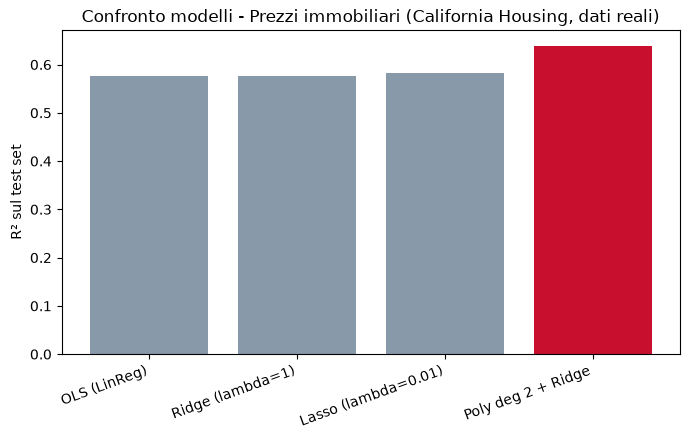

In [69]:
plt.figure()

nomi = tabella["Modello"]           # nomi dei modelli, per l'asse x
valori_r2 = tabella["R2"]           # valori di R2, per l'altezza delle barre

# Coloriamo di rosso solo l'ultimo modello (Poly + Ridge), per evidenziarlo
# visivamente rispetto ai tre modelli lineari semplici
colori = ["#8899aa", "#8899aa", "#8899aa", "#C8102E"]

plt.bar(nomi, valori_r2, color=colori)
plt.ylabel("R² sul test set")
plt.title("Confronto modelli - Prezzi immobiliari (California Housing, dati reali)")
plt.xticks(rotation=20, ha="right")   # ruotiamo le etichette per farle stare tutte leggibili
plt.tight_layout()                     # evita che le etichette vengano tagliate ai bordi
plt.show()

## Conclusioni

Stessa lettura della slide originale, questa volta sui dati veri: si
parte da una baseline semplice (OLS), si verifica se la regolarizzazione
cambia qualcosa (Ridge/Lasso), e infine si verifica se il modello
lineare puro sta perdendo della non linearita reale nei dati aggiungendo
feature polinomiali.